# Project 2: Credit Risk and Statistical Learning

**Names of all group members:**
- Firstname Lastname (email@example.com)
- Firstname Lastname (email@example.com)

In [23]:
import numpy as np
import pandas as pd

## 1

In [ ]:
def gen_features(m: int, n: int, random_seed: int = 0) -> pd.DataFrame:
    """
    Generate (m + n) feature vectors for loan applicants.

    Each applicant i has:
        x_i1: age                  ~ Uniform[18, 80]
        x_i2: monthly income (CHF)~ Uniform[1, 15]
        x_i3: employment status    ~ Bernoulli(p = 0.1), where:
                                    1 = self-employed
                                    0 = salaried

    All three coordinates are assumed independent.

    Parameters
    ----------
    m : int
        Number of training samples.
    n : int
        Number of test samples.
    random_seed : int or None, optional

    Returns
    -------
    features_df : pandas.DataFrame
        DataFrame with (m + n) rows and 3 columns:
            - "age"
            - "income"
            - "employment"
    """

    total_samples = m + n
    rng = np.random.default_rng(seed=random_seed) # Use numpy's random generator

    ## Simulate features
    ages = rng.integers(18, 80, size=total_samples)
    incomes = rng.uniform(low=1.0, high=15.0, size=total_samples)
    employment_status = rng.binomial(1, 0.1, size=total_samples)

    # Create DataFrame
    features_df = pd.DataFrame({
        "age": ages,
        "income": incomes,
        "employment": employment_status
    })

    return features_df

In [12]:
def compute_empirical_stats(features: pd.DataFrame, m: int) -> tuple[pd.Series, pd.Series]:
    """
    Compute empirical mean and variance of each feature using the training set.

    Parameters
    ----------
    features : pandas.DataFrame
        DataFrame containing features for all applicants.
    m : int
        Number of training samples.

    Returns
    -------
    means : pandas.Series
        Empirical means of each feature.
    variances : pandas.Series
        Empirical variances of each feature.
    """

    training_features = features.iloc[:m]

    means = training_features.mean()
    stds = training_features.std()

    return means, stds

In [31]:
m, n = 20000, 10000
features = gen_features(m, n, random_seed=42)
means, stds = compute_empirical_stats(features, m)
print(features.head())
print("Empirical Means:\n", means)
print("Empirical Standard Deviations:\n", stds)

   age     income  employment
0   23   5.865770           0
1   65   2.439301           0
2   58   5.228959           0
3   45  12.293889           0
4   44   7.908713           0
Empirical Means:
 age           48.280800
income         8.019021
employment     0.098950
dtype: float64
Empirical Standard Deviations:
 age           17.867899
income         4.048264
employment     0.298602
dtype: float64


In [36]:
(features['employment'] == 0).sum()

np.int64(26989)

dayum that's a lot of unemployed people lol

Some other realistic variables that might be used for credit scoring are:
- Debt to income ratio
- Past defaults/delinquencies
- Savings ammount
- Existing credit history (Although for Switzerland this is not usefull)

## 2

In [20]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    """
    Standard logistic (sigmoid) function:
        σ(z) = 1 / (1 + exp(-z))
    """
    return 1.0 / (1.0 + np.exp(-z))

In [25]:
def p1_probability(features: pd.DataFrame) -> np.ndarray:
    """
    Compute repayment probabilities p1(x) for each row in `features`.

    Model 1:
        p1(x) = σ( 13.3 - 0.33 * age + 3.5 * income - 3 * employment )

    Here:
        - age              = features["age"]
        - income      = features["income"]
        - employment = features["employment"] (0 or 1)

    Returns
    -------
    probs : np.ndarray
        Array of repayment probabilities p1(x_i) with shape (n_samples,).
    """
    age = features["age"].to_numpy()
    income = features["income"].to_numpy()
    emp = features["employment"].to_numpy()

    # Linear predictor for model 1
    z = 13.3 - 0.33 * age + 3.5 * income - 3.0 * emp

    # Apply sigmoid to obtain probabilities in (0,1)
    probs = sigmoid(z)
    return probs

def p2_probability(features: pd.DataFrame) -> np.ndarray:
    """
    Compute repayment probabilities p2(x) for each row in `features`.

    Model 2 (piecewise in age via indicator functions):

        Let:
            young = 1 if age <= 25, else 0
            old   = 1 if age >= 75, else 0

        Then:
            p2(x) = σ( -5 - 10 * young - 10 * old + 1.1 * income - 1.0 * employment )

    Returns
    -------
    probs : np.ndarray
        Array of repayment probabilities p2(x_i) with shape (n_samples,).
    """
    age = features["age"].to_numpy()
    income = features["income"].to_numpy()
    emp = features["employment"].to_numpy()

    # Indicator variables for age
    # young = 1 if age in (18, 25], old = 1 if age in [75, 80]
    young = (age <= 25.0).astype(float)
    old = (age >= 75.0).astype(float)

    # Linear predictor for model 2
    z = -5.0 - 10.0 * young - 10.0 * old + 1.1 * income - 1.0 * emp

    probs = sigmoid(z)
    return probs

In [26]:
def generate_repayment_data(
    features: pd.DataFrame,
    random_seed: int = 0,
) -> pd.DataFrame:
    """
    Given a matrix of features X (as a DataFrame), generate repayment
    outcomes y^1 and y^2 for both models using a common Uniform(0,1)
    random variable ε_i for each applicant i.

    Parameters
    ----------
    features : pd.DataFrame
        Must contain at least the columns:
            "age", "income", "employment".
        It should have (m + n) rows.
    random_seed : int or None, optional

    Returns
    -------
    data : pd.DataFrame
        Copy of `features` with 4 new columns:
            - "p1_true": p1(x_i)
            - "p2_true": p2(x_i)
            - "y1": repayment indicator under model 1
            - "y2": repayment indicator under model 2
    """
    n_samples = len(features)

    # Set up RNG
    rng = np.random.default_rng(seed=random_seed)

    # 1) Compute true repayment probabilities under each model
    p1 = p1_probability(features)  # shape (n_samples,)
    p2 = p2_probability(features)  # shape (n_samples,)

    # 2) Draw a single Uniform(0,1) value ε_i for each applicant i
    eps = rng.uniform(low=0.0, high=1.0, size=n_samples)

    # 3) Generate repayment indicators using the same ε_i for both models
    y1 = (eps <= p1).astype(int)  # 1 = repay, 0 = default
    y2 = (eps <= p2).astype(int)

    # 4) Build output DataFrame (do not modify input in-place)
    data = features.copy()
    data["p1_true"] = p1
    data["p2_true"] = p2
    data["y1"] = y1
    data["y2"] = y2

    return data

In [28]:
data = generate_repayment_data(features, random_seed=0)
print(data.head(-10))

       age     income  employment   p1_true   p2_true  y1  y2
0       23   5.865770           0  1.000000  0.000194   1   0
1       65   2.439301           0  0.595694  0.089744   1   0
2       58   5.228959           0  0.999996  0.679583   1   1
3       45  12.293889           0  1.000000  0.999801   1   1
4       44   7.908713           0  1.000000  0.975863   1   1
...    ...        ...         ...       ...       ...  ..  ..
29985   29   8.052247           0  1.000000  0.979316   1   0
29986   50   6.175326           0  1.000000  0.857277   1   1
29987   39   8.891286           0  1.000000  0.991677   1   1
29988   31   8.276815           0  1.000000  0.983769   1   1
29989   65  14.600187           0  1.000000  0.999984   1   1

[29990 rows x 7 columns]


In [37]:
# Exercise 2. a)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

In [38]:
def prepare_train_test(
    data: pd.DataFrame,
    target_col: str,
    m: int,
    feature_cols: list[str] = None,
):
    """
    Split the full DataFrame into training and test sets.

    Parameters
    ----------
    data : pd.DataFrame
        Full dataset with (m + n) rows.
    target_col : str
        Name of the target column to predict ("y1" or "y2").
    m : int
        Number of training samples (first m rows are training).
    feature_cols : list of str or None, optional
        Names of feature columns. If None, we default to:
            ["age", "income", "employment"].

    Returns
    -------
    X_train : np.ndarray of shape (m, d)
    y_train : np.ndarray of shape (m,)
    X_test  : np.ndarray of shape (n, d)
    y_test  : np.ndarray of shape (n,)
    """
    # If no specific feature list is given, use the standard three
    if feature_cols is None:
        feature_cols = ["age", "income", "employment"]

    # Extract feature matrix and target vector as NumPy arrays
    X = data[feature_cols].to_numpy()
    y = data[target_col].to_numpy()

    # First m rows: training set
    X_train = X[:m, :]
    y_train = y[:m]

    # Remaining rows: test set
    X_test = X[m:, :]
    y_test = y[m:]

    return X_train, y_train, X_test, y_test

In [41]:
def fit_logistic_regression(X_train: np.ndarray, y_train: np.ndarray) -> LogisticRegression:
    """
    Fit a simple logistic regression model using scikit-learn.

    We do NOT do any fancy preprocessing here:
    - no feature scaling,
    - default L2 regularization,
    - just more iterations to ensure convergence.

    Parameters
    ----------
    X_train : np.ndarray
        Training feature matrix of shape (m, d).
    y_train : np.ndarray
        Training labels (0/1) of shape (m,).

    Returns
    -------
    model : LogisticRegression
        Fitted logistic regression model.
    """
    model = LogisticRegression(
        solver="lbfgs",  # standard solver
        max_iter=1000,   # more iterations just to be safe
    )
    model.fit(X_train, y_train)
    return model

def cross_entropy_loss(y_true: np.ndarray, p_hat: np.ndarray) -> float:
    """
    Compute the (average) cross-entropy loss for binary labels.

    Formula:
        L = - (1/N) * sum_{i=1}^N [ y_i * log(p_i) + (1 - y_i) * log(1 - p_i) ]

    where:
        - y_i are the true labels in {0,1}
        - p_i are the predicted probabilities P(y=1 | x_i)

    Parameters
    ----------
    y_true : np.ndarray
        Vector of true labels in {0,1}.
    p_hat : np.ndarray
        Vector of predicted probabilities in [0,1].

    Returns
    -------
    loss : float
        Cross-entropy loss (smaller is better).
    """
    # Small epsilon to avoid log(0)
    eps = 1e-15

    # Clip predicted probabilities to stay away from 0 and 1
    p_hat_clipped = np.clip(p_hat, eps, 1.0 - eps)

    # Compute each term y_i * log(p_i) + (1 - y_i) * log(1 - p_i)
    term1 = y_true * np.log(p_hat_clipped)
    term2 = (1 - y_true) * np.log(1.0 - p_hat_clipped)

    # Average cross-entropy
    loss = -np.mean(term1 + term2)
    return loss

def evaluate_logistic_model(
    model: LogisticRegression,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
):
    """
    Compute predicted probabilities and cross-entropy losses
    for both TRAINING and TEST sets.

    Parameters
    ----------
    model : LogisticRegression
        Fitted logistic regression.
    X_train, y_train : np.ndarray
        Training data.
    X_test, y_test : np.ndarray
        Test data.

    Returns
    -------
    results : dict
        Dictionary with:
            - "p_train": predicted probabilities on train set
            - "p_test" : predicted probabilities on test set
            - "ce_train": cross-entropy on train set
            - "ce_test" : cross-entropy on test set
    """
    # predict_proba returns a matrix with 2 columns:
    #   [:,0] = P(y=0 | x), [:,1] = P(y=1 | x)
    p_train = model.predict_proba(X_train)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]

    # Compute cross-entropy losses
    ce_train = cross_entropy_loss(y_train, p_train)
    ce_test = cross_entropy_loss(y_test, p_test)

    results = {
        "p_train": p_train,
        "p_test": p_test,
        "ce_train": ce_train,
        "ce_test": ce_test,
    }
    return results

In [53]:
X_train, y1_train, X_test, y1_test = prepare_train_test(data, target_col="y1", m=m)
log_model1 = fit_logistic_regression(X_train, y1_train)
log_results1 = evaluate_logistic_model(log_model1, X_train, y1_train, X_test, y1_test)
print("Logistic Regression Model 1 Cross-Entropy Loss:")
print("  Train:", log_results1["ce_train"])
print("  Test :", log_results1["ce_test"])

Logistic Regression Model 1 Cross-Entropy Loss:
  Train: 0.03246888935687466
  Test : 0.030431502286298262


In [52]:
X_train, y2_train, X_test, y2_test = prepare_train_test(data, target_col="y2", m=m)
log_model2 = fit_logistic_regression(X_train, y2_train)
log_results2 = evaluate_logistic_model(log_model2, X_train, y2_train, X_test, y2_test)
print("Logistic Regression Model 2 Cross-Entropy Loss:")
print("  Train:", log_results2["ce_train"])
print("  Test :", log_results2["ce_test"])

Logistic Regression Model 2 Cross-Entropy Loss:
  Train: 0.47956052297084295
  Test : 0.48036482417260484


In [45]:
# Exercise 2. b)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [ ]:
def standardize_train_test(X_train: np.ndarray, X_test: np.ndarray):
    """
    Standardize features:

        For each feature j:
            mean_j = average of column j on the TRAINING set
            std_j  = standard deviation of column j on the TRAINING set

        Then:
            X_std[:, j] = (X[:, j] - mean_j) / std_j

    IMPORTANT:
    ---------
    - We fit the scaler on the TRAINING data only.
    - We then apply the same transformation to the TEST data.

    Parameters
    ----------
    X_train : np.ndarray
        Training feature matrix of shape (m, d).
    X_test : np.ndarray
        Test feature matrix of shape (n, d).

    Returns
    -------
    X_train_std : np.ndarray
        Standardized training features.
    X_test_std : np.ndarray
        Standardized test features.
    scaler : StandardScaler
        Fitted scaler (in case you want to reuse it).
    """
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_test_std = scaler.transform(X_test)
    return X_train_std, X_test_std, scaler

In [ ]:
def fit_svm_classifier(X_train_std: np.ndarray, y_train: np.ndarray, C: float = 1.0, kernel: str = "rbf", gamma: str = "scale") -> SVC:
    """
    Fit a Support Vector Machine (SVM) classifier with probability outputs.

    We keep the setup simple:
        - RBF kernel (non-linear)
        - Default C and gamma (you can change them later if needed)
        - probability=True so we can call predict_proba and compute cross-entropy

    Parameters
    ----------
    X_train_std : np.ndarray
        Standardized training features of shape (m, d).
    y_train : np.ndarray
        Binary training labels (0/1) of shape (m,).
    C : float, optional
        Regularization parameter. Default = 1.0.
    kernel : str, optional
        Kernel type. Default = "rbf".
    gamma : str, optional
        Kernel coefficient. "scale" is scikit-learn's default.

    Returns
    -------
    model : SVC
        Fitted SVM classifier.
    """
    model = SVC(
        C=C,
        kernel=kernel,
        gamma=gamma,
        probability=True,  # needed to get probabilities
    )
    model.fit(X_train_std, y_train)
    return model

def evaluate_svm_model(model: SVC, X_train_std: np.ndarray, y_train: np.ndarray, X_test_std: np.ndarray, y_test: np.ndarray):
    """
    Compute predicted probabilities and cross-entropy losses
    for both TRAINING and TEST sets using the already defined
    `cross_entropy_loss` function.

    Parameters
    ----------
    model : SVC
        Fitted SVM classifier.
    X_train_std, y_train : np.ndarray
        Standardized training data and labels.
    X_test_std, y_test : np.ndarray
        Standardized test data and labels.

    Returns
    -------
    results : dict
        Dictionary with:
            - "p_train": predicted probabilities on train set
            - "p_test" : predicted probabilities on test set
            - "ce_train": cross-entropy on train set
            - "ce_test" : cross-entropy on test set
    """
    # As with logistic regression, predict_proba returns:
    #   [:,0] = P(y=0 | x), [:,1] = P(y=1 | x)
    p_train = model.predict_proba(X_train_std)[:, 1]
    p_test = model.predict_proba(X_test_std)[:, 1]

    # We REUSE the cross_entropy_loss function from before.
    ce_train = cross_entropy_loss(y_train, p_train)
    ce_test = cross_entropy_loss(y_test, p_test)

    results = {
        "p_train": p_train,
        "p_test": p_test,
        "ce_train": ce_train,
        "ce_test": ce_test,
    }
    return results

In [48]:
X_train, y1_train, X_test, y1_test = prepare_train_test(data, target_col="y1", m=m)
X_train, X_test, scaler = standardize_train_test(X_train, X_test)
svm_model1 = fit_svm_classifier(X_train, y1_train)
results_svm1 = evaluate_svm_model(svm_model1, X_train, y1_train, X_test, y1_test)
print("SVM Model 1 Cross-Entropy Loss:")
print("  Train:", results_svm1["ce_train"])
print("  Test :", results_svm1["ce_test"])

SVM Model 1 Cross-Entropy Loss:
  Train: 0.04031641280142543
  Test : 0.03663411572113411


In [51]:
X_train, y2_train, X_test, y2_test = prepare_train_test(data, target_col="y2", m=m)
X_train, X_test, scaler = standardize_train_test(X_train, X_test)
svm_model2 = fit_svm_classifier(X_train, y2_train)
results_svm2 = evaluate_svm_model(svm_model2, X_train, y2_train, X_test, y2_test)
print("SVM Model 2 Cross-Entropy Loss:")
print("  Train:", results_svm2["ce_train"])
print("  Test :", results_svm2["ce_test"])

SVM Model 2 Cross-Entropy Loss:
  Train: 0.24465626000093443
  Test : 0.2614213628206474


damn, that takes some time to run...

In [57]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [56]:
def compute_roc_auc(y_true: np.ndarray, p_hat: np.ndarray):
    """
    Compute ROC curve and AUC given true labels and predicted probabilities.

    Parameters
    ----------
    y_true : np.ndarray
        Binary true labels (0/1), shape (n_samples,)
    p_hat : np.ndarray
        Predicted probabilities P(y=1|x), shape (n_samples,)

    Returns
    -------
    fpr : np.ndarray
        False positive rate values for different thresholds.
    tpr : np.ndarray
        True positive rate values for different thresholds.
    roc_auc : float
        Area under the ROC curve.
    """
    # roc_curve returns (FPR, TPR, thresholds)
    fpr, tpr, _ = roc_curve(y_true, p_hat)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

def plot_roc_curve(fpr, tpr, roc_auc: float, title: str):
    """
    Plot ROC curve with diagonal reference line and AUC in the legend.

    Parameters
    ----------
    fpr : np.ndarray
        False positive rate values.
    tpr : np.ndarray
        True positive rate values.
    roc_auc : float
        Area under the ROC curve.
    title : str
        Title for the plot.
    """
    plt.figure()
    # ROC curve
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
    # Diagonal baseline
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random guess")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

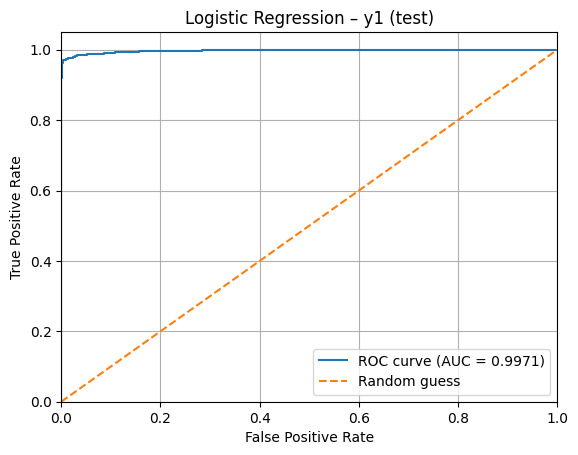

In [58]:
fpr_log_y1, tpr_log_y1, auc_log_y1 = compute_roc_auc(y1_test, log_results1["p_test"])
plot_roc_curve(fpr_log_y1, tpr_log_y1, auc_log_y1,"Logistic Regression – y1 (test)")

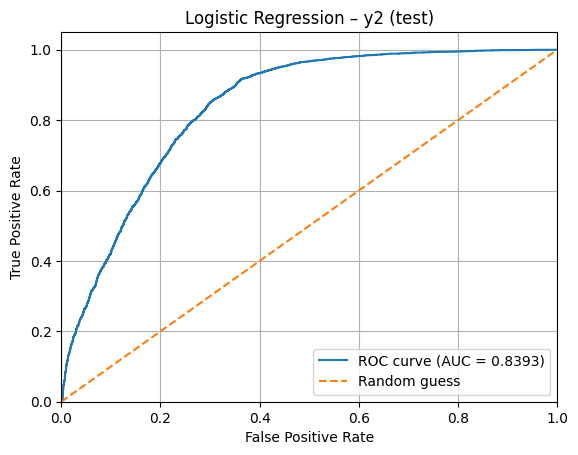

In [62]:
fpr_log_y2, tpr_log_y2, auc_log_y2 = compute_roc_auc(y2_test, log_results2["p_test"])
plot_roc_curve(fpr_log_y2, tpr_log_y2, auc_log_y2,"Logistic Regression – y2 (test)")

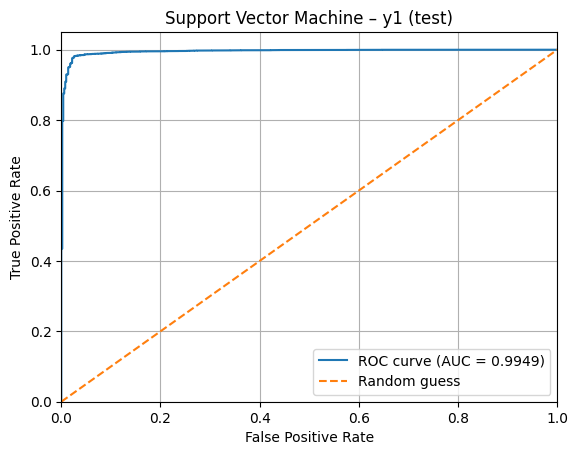

In [64]:
fpr_svm_y1, tpr_svm_y1, auc_svm_y1 = compute_roc_auc(y1_test, results_svm1["p_test"])
plot_roc_curve(fpr_svm_y1, tpr_svm_y1, auc_svm_y1,"Support Vector Machine – y1 (test)")

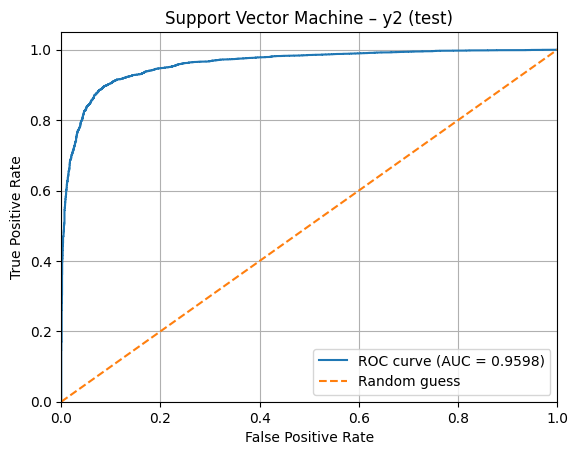

In [63]:
fpr_svm_y2, tpr_svm_y2, auc_svm_y2 = compute_roc_auc(y2_test, results_svm2["p_test"])
plot_roc_curve(fpr_svm_y2, tpr_svm_y2, auc_svm_y2,"Support Vector Machine – y2 (test)")

In [ ]:
# Exercise 3.

# Set model parameters and define matrix D


# Scenario 1:
# Define Portfolio and possible outcomes for this portfolio using matrix D


# Plot the histogram of profits and losses


# Calculate expected profit and losses, compute 95%-VaR and 95%-ES


# Scenario 2:
# Define Portfolio and possible outcomes using the matrix D and the predicted default probabilities from the logistic regression model


# Plot the histogram of profits and losses


# Calculate expected profit and losses, compute 95%-VaR and 95%-ES


# Scenario 3:
# Define Portfolio and possible outcomes using the matrix D and the predicted default probabilities from the SVM model


# Plot the histogram of profits and losses


# Calculate expected profit and losses, compute 95%-VaR and 95%-ES